
# Episode 3 — Sport Agent Showdown

**Question:** can one sports agent answer football, F1 and chess questions without mixing facts?

This notebook tells the end-to-end story behind Episode 3. We compare four agentic designs:

1. `single_agent`
2. `sequential_chain`
3. `triage_handoff`
4. `committee_referee`

The task is intentionally multi-domain: World Cup 2026 groups, Formula 1 2026 schedules/lineups, chess ratings, and legacy football player stats.



## 1. Setup

The notebook runs in deterministic offline mode. The optional live OpenAI path is implemented in `src/sport_agent/openai_agents.py`, but not used here so the experiment is reproducible without API cost.


In [1]:

from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from sport_agent.data import world_cup_groups, f1_calendar, f1_lineups, chess_top_players, source_cards
from sport_agent.designs import run_design, DESIGNS
from sport_agent.eval_harness import evaluate_design, summarise, load_eval_cases

print(ROOT)


/mnt/data/sport-agent-showdown-episode3



## 2. Data snapshot

This is not a live sports database. It is a compact, source-backed snapshot used for a controlled agent-engineering experiment.


In [2]:

wc = world_cup_groups()['groups']
teams = [team for group in wc.values() for team in group]
summary = {
    'World Cup groups': len(wc),
    'World Cup teams': len(teams),
    'Italy in World Cup snapshot?': 'Italy' in teams,
    'F1 current schedule rounds': len(f1_calendar()['rounds']),
    'F1 teams in line-up snapshot': len(f1_lineups()['lineups']),
    'Chess players in rating snapshot': len(chess_top_players()['players']),
    'RAG source cards': len(source_cards()),
}
display(pd.DataFrame([summary]).T.rename(columns={0:'value'}))


,value
World Cup groups,12
World Cup teams,48
Italy in World Cup snapshot?,False
F1 current schedule rounds,22
F1 teams in line-up snapshot,11
Chess players in rating snapshot,11
RAG source cards,9



## 3. Example questions

The benchmark contains questions that force routing, retrieval, source conflicts, abstention, and mixed-sport decomposition.


In [3]:

cases = load_eval_cases()
display(pd.DataFrame([{
    'case_id': c.case_id,
    'sports': ', '.join(c.expected_sports),
    'question': c.question,
    'should_abstain': c.should_abstain,
} for c in cases]).head(15))


,case_id,sports,question,should_abstain
0,football_italy_absent,football,Is Italy in the 2026 FIFA World Cup field?,False
1,football_group_d,football,Who are the teams in World Cup 2026 Group D?,False
2,f1_mclaren_lineup,f1,Who drives for McLaren in the 2026 F1 season?,False
3,f1_calendar_conflict,f1,How many races are in the current 2026 F1 sche...,False
4,chess_top5,chess,Who are the top 5 classical chess players on t...,False
5,mixed_carlsen_argentina_group,"chess, football","What is Magnus Carlsen's May 2026 FIDE rank, a...",False
6,football_legacy_compare,football,Compare Johan Cruyff and Michel Platini by int...,False
7,f1_false_verstappen_ferrari,f1,I heard Max Verstappen drives for Ferrari in 2...,False
8,mixed_simple_math,"chess, football",Which is larger: Magnus Carlsen's May 2026 cla...,False
9,f1_prediction_no_guarantee,f1,Can you guarantee who will win the next F1 rac...,True



## 4. Same question, four designs

This mixed briefing question is where a single generalist starts to break down. The handoff and committee designs explicitly split the work by sport.


In [4]:

question = 'Build me a mini sports briefing: World Cup Group D, the next F1 race, and the chess number one.'
rows = []
for design in DESIGNS:
    ans = run_design(question, design)
    rows.append({
        'design': design,
        'sports': ', '.join(ans.sports),
        'tools': ', '.join(ans.tools_used),
        'skills': ', '.join(ans.skills_used),
        'citations': ', '.join(ans.citations),
        'abstained': ans.abstained,
        'answer': ans.answer,
    })
display(pd.DataFrame(rows))


,design,sports,tools,skills,citations,abstained,answer
0,single_agent,football,search_source_cards,"football-research, mixed-question-decomposition",fifa_wc26_final_groups,False,"World Cup 2026 Group D is USA, Paraguay, Austr..."
1,sequential_chain,"football, f1, chess","get_world_cup_group, get_f1_calendar, get_ches...","football-research, f1-research, chess-research...","fifa_wc26_final_groups, f1_2026_calendar_curre...",False,"World Cup 2026 Group D is USA, Paraguay, Austr..."
2,triage_handoff,"football, f1, chess","get_world_cup_group, get_f1_calendar, get_ches...","football-research, f1-research, chess-research...","fifa_wc26_final_groups, f1_2026_calendar_curre...",False,"World Cup 2026 Group D is USA, Paraguay, Austr..."
3,committee_referee,"football, f1, chess","get_world_cup_group, get_f1_calendar, get_ches...","football-research, f1-research, chess-research...","fifa_wc26_final_groups, f1_2026_calendar_curre...",False,"World Cup 2026 Group D is USA, Paraguay, Austr..."



## 5. Run the evaluation harness

The harness checks route accuracy, tool recall, skill recall, citation recall, expected keywords, forbidden claims, abstention accuracy, unsupported claims, and cost/tool-call proxies.


In [5]:

summaries = []
all_results = {}
for design in DESIGNS:
    results = evaluate_design(design)
    all_results[design] = results
    summaries.append(summarise(results))
summary_df = pd.DataFrame(summaries)
display(summary_df)


,design,cases,pass_rate,route_accuracy,tool_recall,skill_recall,citation_recall,keyword_recall,forbidden_absence,abstention_accuracy,unsupported_claim_rate,avg_tool_calls,avg_cost_proxy
0,single_agent,15,0.000000,0.888889,0.1,0.793333,0.488889,0.58,0.866667,0.866667,0.666667,1.000000,1.350000
1,sequential_chain,15,0.933333,1.000000,1.0,1.000000,1.000000,1.00,1.000000,0.933333,0.000000,1.533333,2.052333
2,triage_handoff,15,1.000000,1.000000,1.0,1.000000,1.000000,1.00,1.000000,1.000000,0.000000,1.533333,2.584000
3,committee_referee,15,1.000000,1.000000,1.0,1.000000,1.000000,1.00,1.000000,1.000000,0.000000,2.266667,4.208000



## 6. Visual comparison

The figures below are generated by `scripts/make_figures.py` after evaluation. They show that `triage_handoff` gets the best quality/cost balance in this deterministic benchmark, while `committee_referee` matches quality with more tool calls.


### design_pass_rate.png

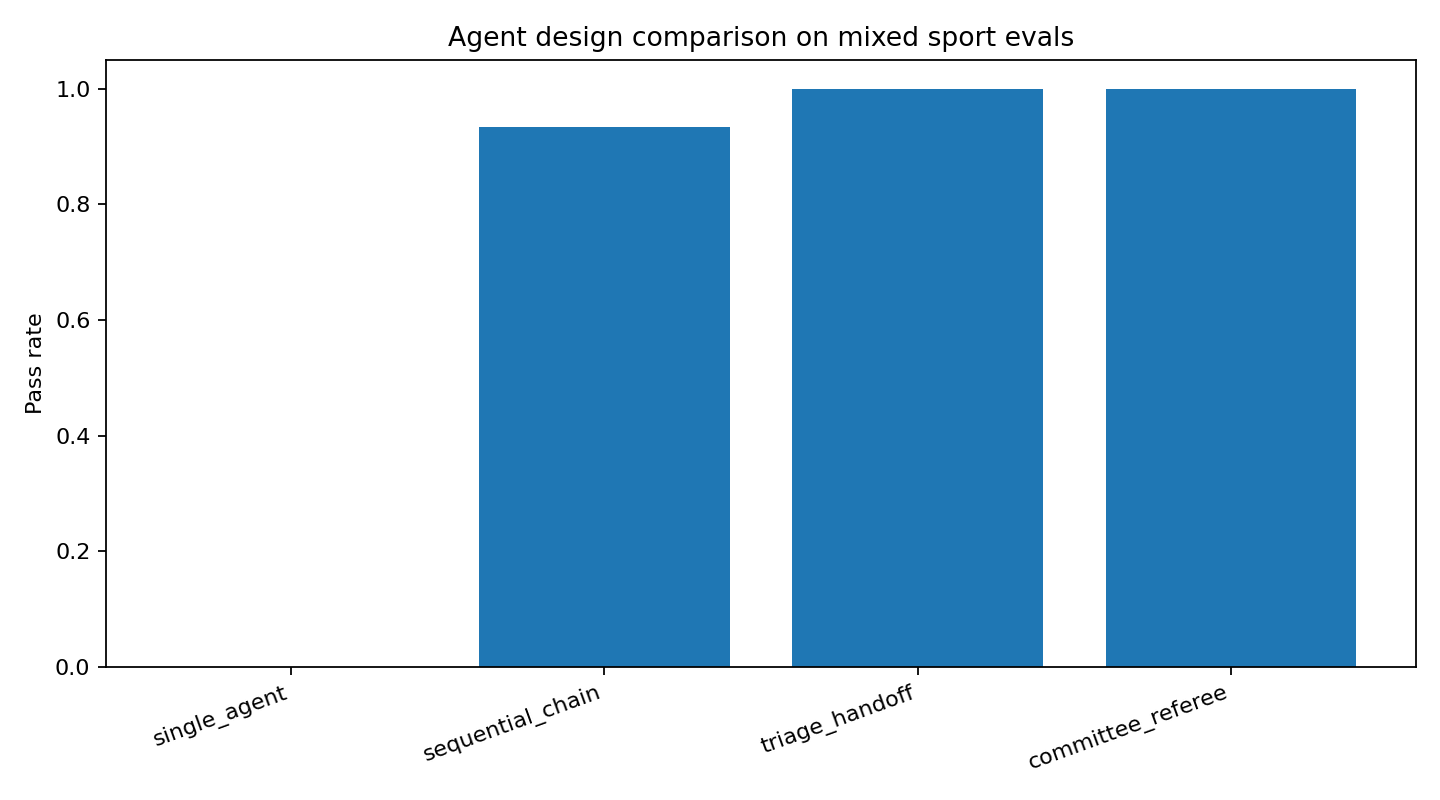

### tool_cost_tradeoff.png

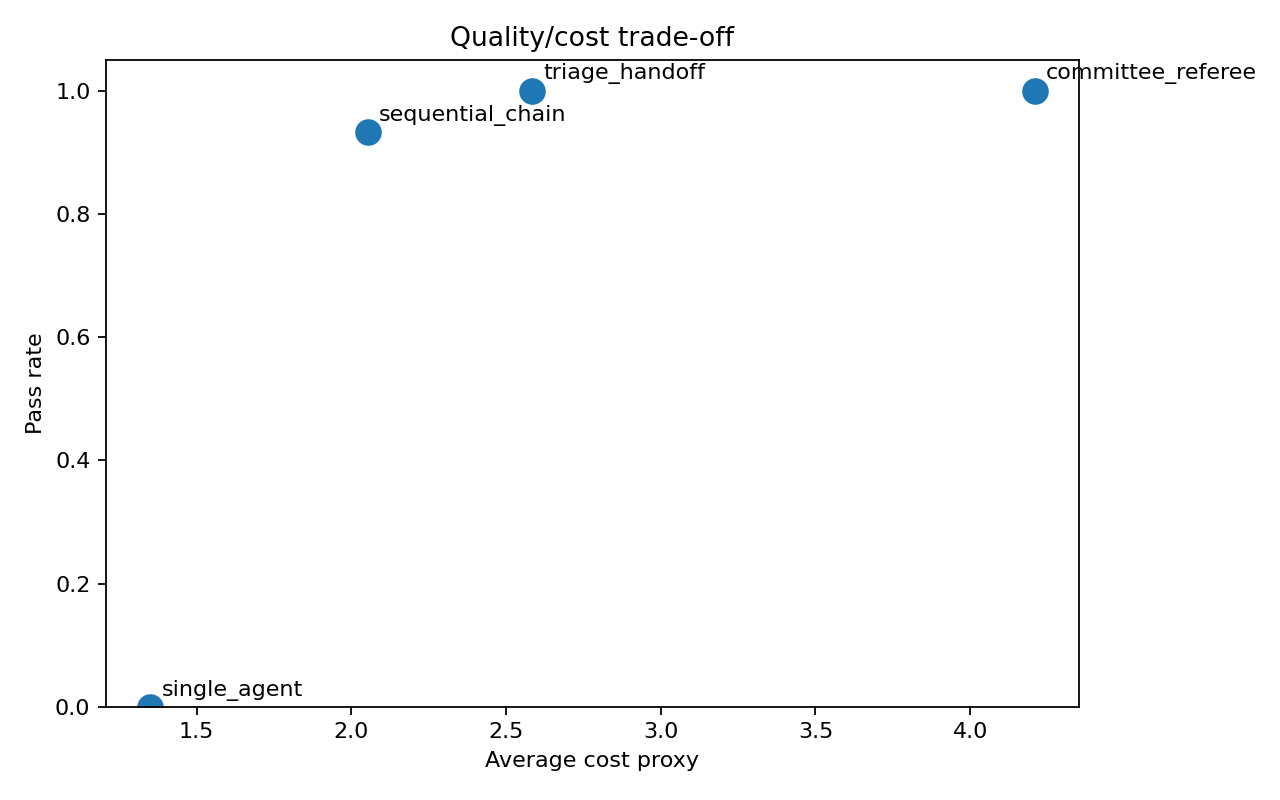

### metric_radar_like.png

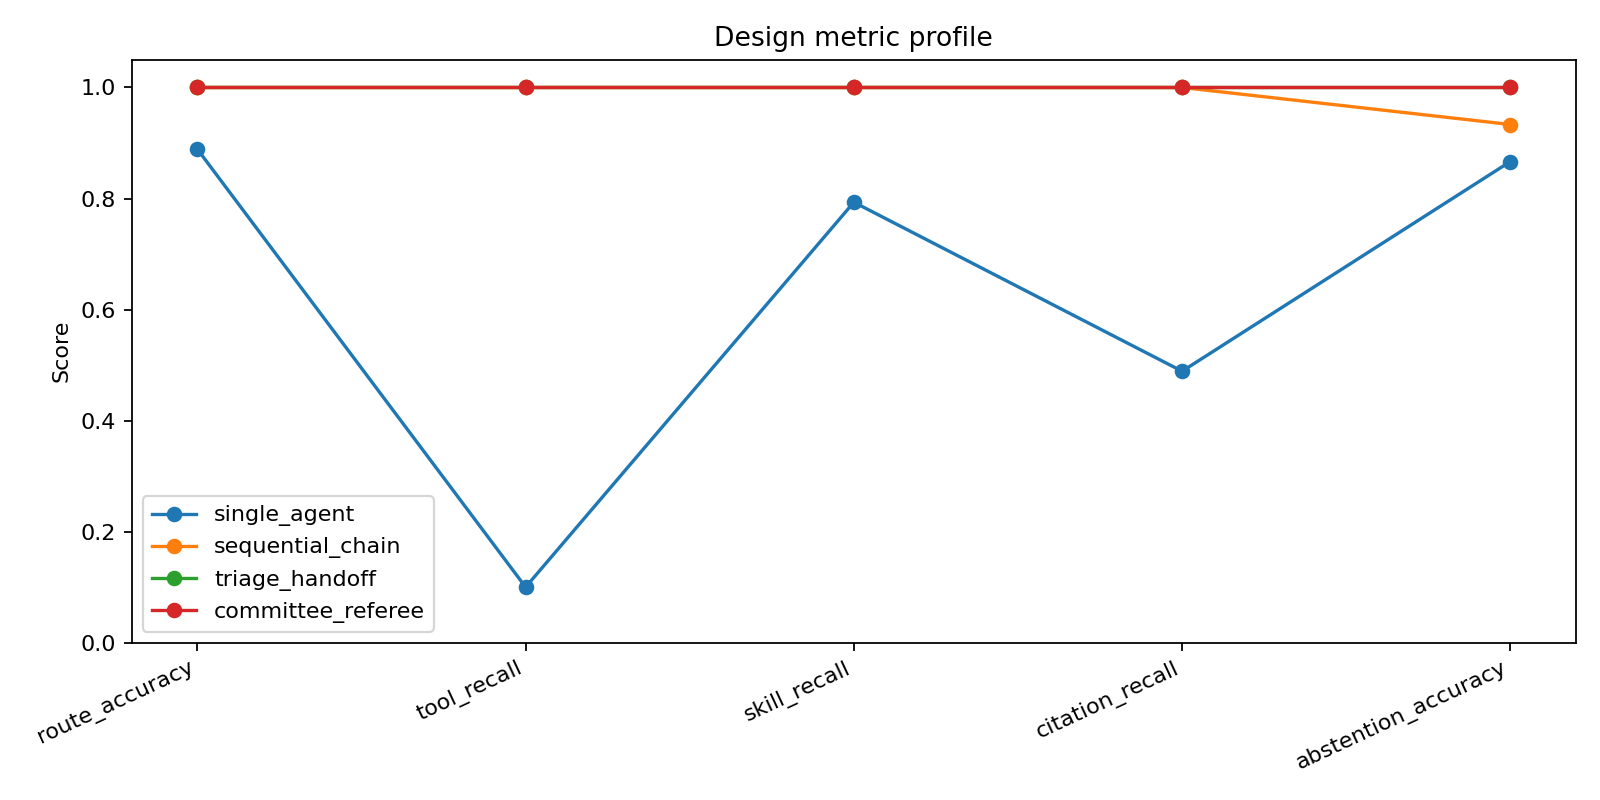

In [6]:

for img in [
    'reports/figures/design_pass_rate.png',
    'reports/figures/tool_cost_tradeoff.png',
    'reports/figures/metric_radar_like.png',
]:
    display(Markdown(f'### {Path(img).name}'))
    display(Image(filename=str(ROOT / img)))



## 7. Failure analysis

The single-agent design looks simple, but the eval makes its weaknesses visible: weak tool discipline, incomplete citations, and poor handling of mixed-domain questions.


In [7]:

failure_rows = []
for design, results in all_results.items():
    for r in results:
        if not r.passed:
            failure_rows.append({
                'design': design,
                'case_id': r.case_id,
                'failures': ', '.join(r.failures),
                'answer': r.answer.answer,
            })
display(pd.DataFrame(failure_rows).head(20))


,design,case_id,failures,answer
0,single_agent,football_italy_absent,"tool_recall, citation_recall, keyword_recall",Italy is a traditional World Cup power and may...
1,single_agent,football_group_d,tool_recall,"World Cup 2026 Group D is USA, Paraguay, Austr..."
2,single_agent,f1_mclaren_lineup,tool_recall,McLaren's 2026 drivers are Lando Norris and Os...
3,single_agent,f1_calendar_conflict,"tool_recall, citation_recall, keyword_recall",The 2026 F1 season has 24 races.
4,single_agent,chess_top5,tool_recall,"The top five are Magnus Carlsen, Hikaru Nakamu..."
5,single_agent,mixed_carlsen_argentina_group,"route_accuracy, tool_recall, skill_recall, cit...",The 2026 FIFA World Cup final groups contain 1...
6,single_agent,football_legacy_compare,"tool_recall, skill_recall, citation_recall, ke...",The Michel Platini source card records the Fra...
7,single_agent,f1_false_verstappen_ferrari,tool_recall,Formula1.com's 2026 line-up article lists McLa...
8,single_agent,mixed_simple_math,"route_accuracy, tool_recall, skill_recall, cit...",RSSSF's Johan Cruyff international goals page ...
9,single_agent,f1_prediction_no_guarantee,"tool_recall, skill_recall, citation_recall, ke...",I cannot guarantee the winner of the next F1 r...



## 8. Design recommendation

For this sport-agent scope:

- **Use `triage_handoff` as the practical default.** It gets perfect eval performance here at lower cost than committee-referee.
- **Use `committee_referee` for higher-stakes answers.** It adds verification and is easier to extend with stricter checks.
- **Avoid relying on a single generalist** for broad sports questions with current facts and mixed domains.

This is the episode's main engineering point: the interesting part is not just adding more data. It is choosing the right agent orchestration pattern for the failure modes.
